In [1]:
import nifty.re as jft
import jax.random as random
import jax
import jax.numpy as jnp
import numpy as np
# from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns

# With Galactic Noise

In [2]:
c_60 = np.load("results/60K_1000samples_size800/Cov.npy")
c_200 = np.load("results/200K_1000samples_size800/Cov.npy")
c_300 = np.load("results/300K_1000samples_size800/Cov.npy")

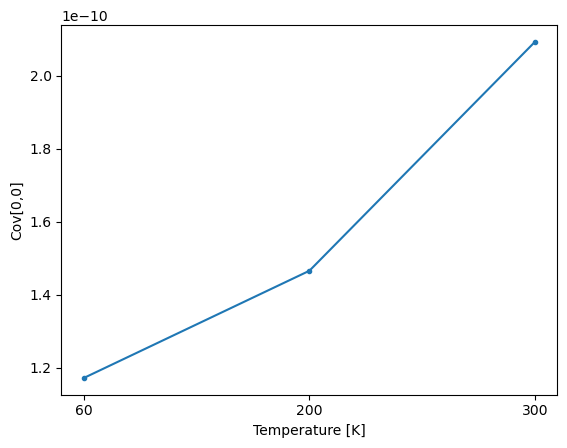

In [3]:
plt.plot(np.arange(3), [c_60[0,0], c_200[0,0], c_300[0,0]], marker=".")
plt.xlabel("Temperature [K]")
plt.xticks(np.arange(3), [60, 200, 300])
plt.ylabel(r"Cov[0,0]")
plt.show()

In [8]:
def transform_cov_for_1D(cov, display_bin):
    rows, cols = cov.shape
    col_indices = (np.arange(rows)[:, None] + np.arange(cols)) % cols
    small_cov = cov[np.arange(rows)[:, None], col_indices][:, :display_bin]
    return small_cov/np.max(small_cov, axis=1)[:, None]

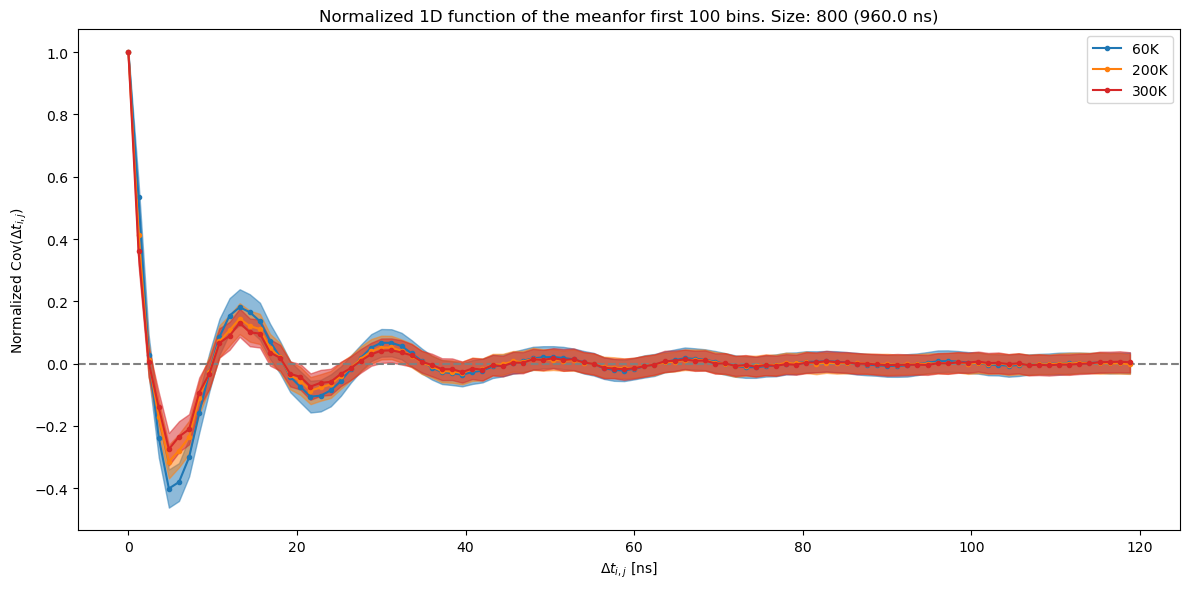

In [18]:
display_bin = 100
dur = c_60.shape[0]

s_60 = transform_cov_for_1D(c_60, display_bin)
mean_60 = np.mean(s_60, axis=0)
stds_60 = np.std(s_60, axis=0)

s_200 = transform_cov_for_1D(c_200, display_bin)
mean_200 = np.mean(s_200, axis=0)
stds_200 = np.std(s_200, axis=0)

s_300 = transform_cov_for_1D(c_300, display_bin)
mean_300 = np.mean(s_300, axis=0)
stds_300 = np.std(s_300, axis=0)

small_x = np.arange(display_bin)*1.2

plt.figure(figsize=(12,6))
plt.axhline(y=0, c="gray", linestyle="--")

plt.fill_between(small_x, mean_60-stds_60, mean_60+stds_60, color="tab:blue", alpha=0.5)
plt.fill_between(small_x, mean_200-stds_200, mean_200+stds_200, color="tab:orange", alpha=0.5)
plt.fill_between(small_x, mean_300-stds_300, mean_300+stds_300, color="tab:red", alpha=0.5)

# plt.plot(small_x, s_60[0], c="tab:blue", marker=".", label="60K")
# plt.plot(small_x, s_200[0], c="tab:orange", marker=".", label="200K")
# plt.plot(small_x, s_300[0], c="tab:red", marker=".", label="300K")

plt.plot(small_x, mean_60, c="tab:blue", marker=".", label="60K")
plt.plot(small_x, mean_200, c="tab:orange", marker=".", label="200K")
plt.plot(small_x, mean_300, c="tab:red", marker=".", label="300K")

plt.legend()

plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
plt.ylabel(r"Normalized Cov($\Delta t_{i,j}$)")

plt.title(f"Normalized 1D function of the meanfor first {display_bin} bins. Size: {dur} ({dur*1.2} ns)")
plt.tight_layout()

plt.show()

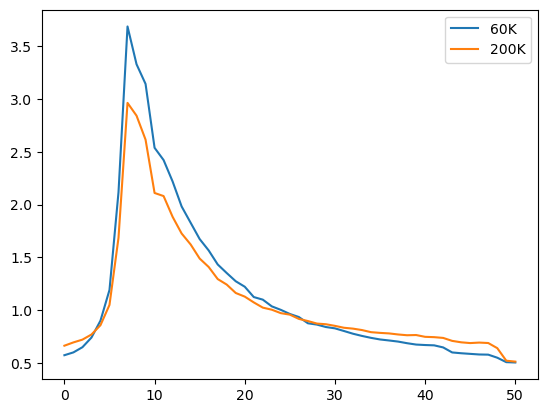

In [24]:
fourier = np.fft.rfft(mean_60)
plt.plot(np.abs(fourier), label="60K")
fourier = np.fft.rfft(mean_200)
plt.plot(np.abs(fourier), label="200K")
plt.legend()
plt.show()

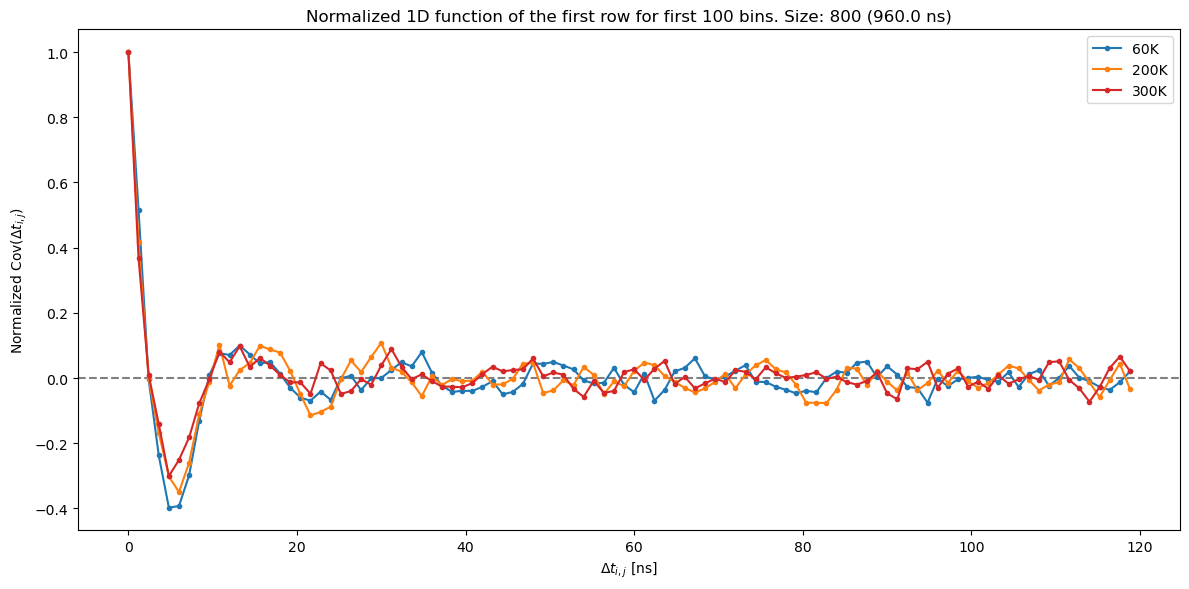

In [11]:
display_bin = 100
dur = c_60.shape[0]

s_60 = transform_cov_for_1D(c_60, display_bin)
mean_60 = np.mean(s_60, axis=0)
stds_60 = np.std(s_60, axis=0)

s_200 = transform_cov_for_1D(c_200, display_bin)
mean_200 = np.mean(s_200, axis=0)
stds_200 = np.std(s_200, axis=0)

s_300 = transform_cov_for_1D(c_300, display_bin)
mean_300 = np.mean(s_300, axis=0)
stds_300 = np.std(s_300, axis=0)

small_x = np.arange(display_bin)*1.2

plt.figure(figsize=(12,6))
plt.axhline(y=0, c="gray", linestyle="--")

# plt.fill_between(small_x, mean_60-stds_60, mean_60+stds_60, color="tab:blue", alpha=0.5)
# plt.fill_between(small_x, mean_200-stds_200, mean_200+stds_200, color="tab:orange", alpha=0.5)
# plt.fill_between(small_x, mean_300-stds_300, mean_300+stds_300, color="tab:red", alpha=0.5)

plt.plot(small_x, s_60[0], c="tab:blue", marker=".", label="60K")
plt.plot(small_x, s_200[0], c="tab:orange", marker=".", label="200K")
plt.plot(small_x, s_300[0], c="tab:red", marker=".", label="300K")

plt.legend()

plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
plt.ylabel(r"Normalized Cov($\Delta t_{i,j}$)")

plt.title(f"Normalized 1D function of the first row for first {display_bin} bins. Size: {dur} ({dur*1.2} ns)")
plt.tight_layout()

plt.show()

# Without Galactic Noise

In [19]:
c_60_ng = np.load("results/NoGal_60K_1000samples_size800/Cov.npy")
c_200_ng = np.load("results/NoGal_200K_1000samples_size800/Cov.npy")
# c_300_ng = np.load("results/NoGal_300K_1000samples_size800/Cov.npy")

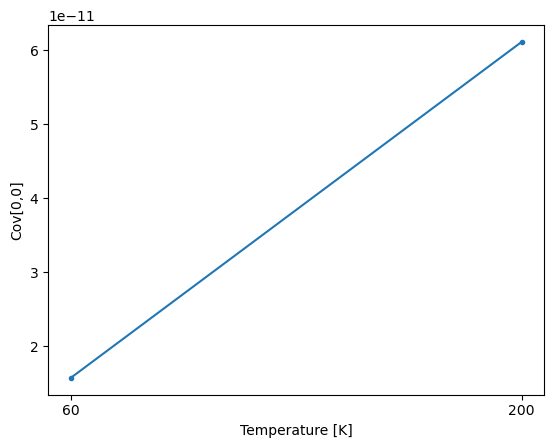

In [20]:
plt.plot(np.arange(2), [c_60_ng[0,0], c_200_ng[0,0]], marker=".")
plt.xlabel("Temperature [K]")
plt.xticks(np.arange(2), [60, 200])
plt.ylabel(r"Cov[0,0]")
plt.show()

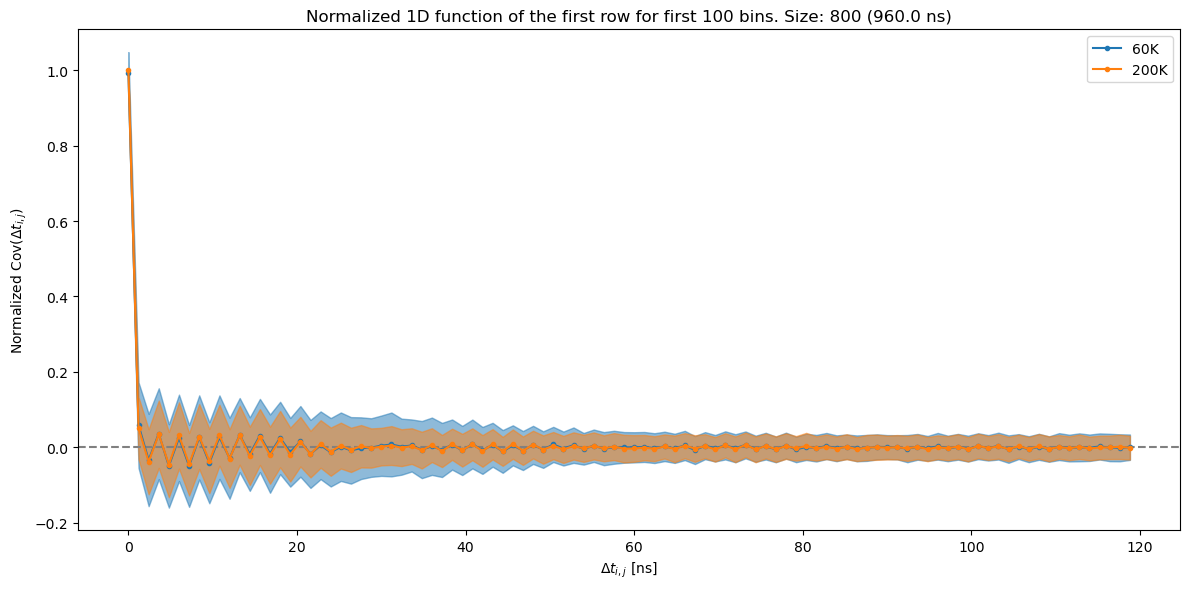

In [21]:
display_bin = 100
dur = c_60.shape[0]

s_60_ng = transform_cov_for_1D(c_60_ng, display_bin)
mean_60_ng = np.mean(s_60_ng, axis=0)
stds_60_ng = np.std(s_60_ng, axis=0)

s_200_ng = transform_cov_for_1D(c_200_ng, display_bin)
mean_200_ng = np.mean(s_200_ng, axis=0)
stds_200_ng = np.std(s_200_ng, axis=0)

small_x = np.arange(display_bin)*1.2

plt.figure(figsize=(12,6))
plt.axhline(y=0, c="gray", linestyle="--")

plt.fill_between(small_x, mean_60_ng-stds_60_ng, mean_60_ng+stds_60_ng, color="tab:blue", alpha=0.5)
plt.fill_between(small_x, mean_200_ng-stds_200_ng, mean_200_ng+stds_200_ng, color="tab:orange", alpha=0.5)

plt.plot(small_x, mean_60_ng, c="tab:blue", marker=".", label="60K")
plt.plot(small_x, mean_200_ng, c="tab:orange", marker=".", label="200K")

plt.legend()

plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
plt.ylabel(r"Normalized Cov($\Delta t_{i,j}$)")

plt.title(f"Normalized 1D function of the first row for first {display_bin} bins. Size: {dur} ({dur*1.2} ns)")
plt.tight_layout()

plt.show()

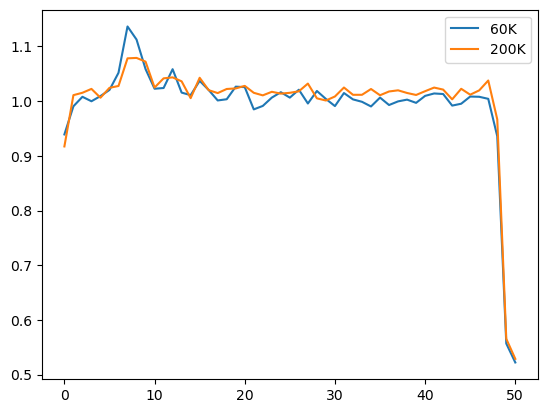

In [25]:
fourier = np.fft.rfft(mean_60_ng)
plt.plot(np.abs(fourier), label="60K")
fourier = np.fft.rfft(mean_200_ng)
plt.plot(np.abs(fourier), label="200K")
plt.legend()
plt.show()

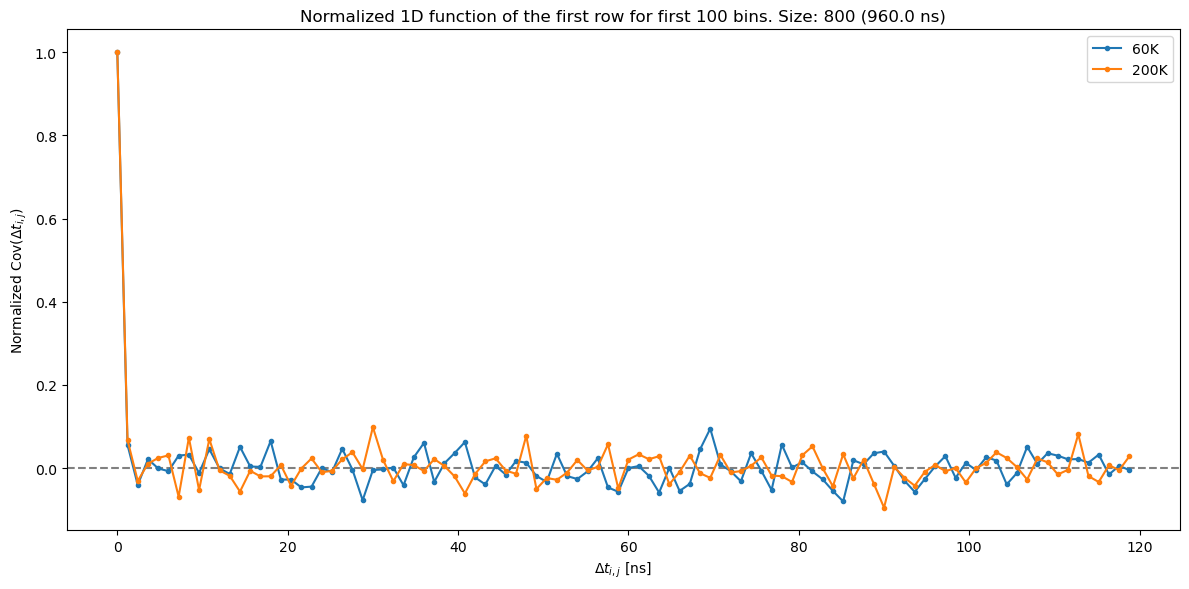

In [22]:
plt.figure(figsize=(12,6))
plt.axhline(y=0, c="gray", linestyle="--")

# plt.fill_between(small_x, mean_60-stds_60, mean_60+stds_60, color="tab:blue", alpha=0.5)
# plt.fill_between(small_x, mean_200-stds_200, mean_200+stds_200, color="tab:orange", alpha=0.5)
# plt.fill_between(small_x, mean_300-stds_300, mean_300+stds_300, color="tab:red", alpha=0.5)

plt.plot(small_x, s_60_ng[0], c="tab:blue", marker=".", label="60K")
plt.plot(small_x, s_200_ng[0], c="tab:orange", marker=".", label="200K")

plt.legend()

plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
plt.ylabel(r"Normalized Cov($\Delta t_{i,j}$)")

plt.title(f"Normalized 1D function of the first row for first {display_bin} bins. Size: {dur} ({dur*1.2} ns)")
plt.tight_layout()

plt.show()

# With/without Galactice Noise

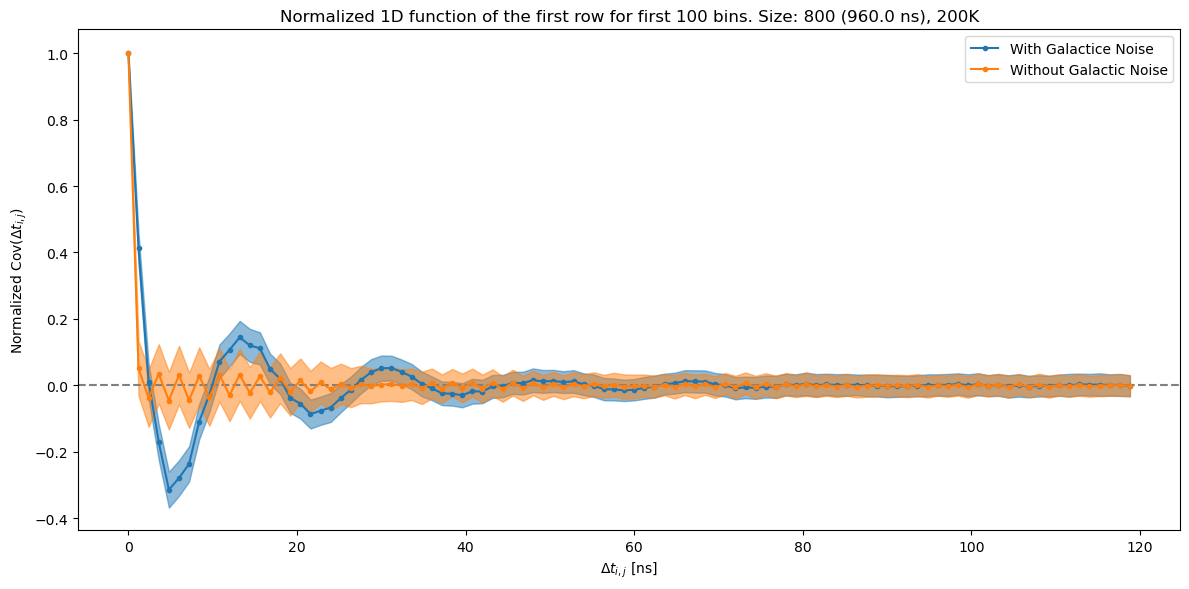

In [23]:
plt.figure(figsize=(12,6))
plt.axhline(y=0, c="gray", linestyle="--")

plt.fill_between(small_x, mean_200-stds_200, mean_200+stds_200, color="tab:blue", alpha=0.5)
plt.fill_between(small_x, mean_200_ng-stds_200_ng, mean_200_ng+stds_200_ng, color="tab:orange", alpha=0.5)

plt.plot(small_x, mean_200, c="tab:blue", marker=".", label="With Galactice Noise")
plt.plot(small_x, mean_200_ng, c="tab:orange", marker=".", label="Without Galactic Noise")

plt.legend()

plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
plt.ylabel(r"Normalized Cov($\Delta t_{i,j}$)")

plt.title(f"Normalized 1D function of the first row for first {display_bin} bins. Size: {dur} ({dur*1.2} ns), 200K")
plt.tight_layout()

plt.show()